In [3]:
# os tools
import sys
import os
import os.path
import requests
import time
import urllib3
import shutil
from tqdm import tqdm

# data tools
import numpy                 as np
import pandas                as pd
import xarray                as xr
from   datetime              import date, datetime, timedelta                 # for saving figures with today's date
import datetime
import scipy
from   scipy.stats           import kruskal              # for boxenplot stats
from   scipy.stats           import mannwhitneyu         # for split violin plot stats
import gsw


# for all plots
import matplotlib
import matplotlib.pyplot     as plt                      # needed to make map setup
import matplotlib.colors     as colors
from   matplotlib.ticker     import EngFormatter         # for degree symbol in axis
from   cmocean               import cm as cmo
import seaborn               as     sns

# for map
import shapefile
import cartopy                                           # to make map
import matplotlib.path       as     mpath                # to draw circle for map
import cartopy.crs           as     ccrs                 # for map projection
import cartopy.feature       as     cfeature             # to add land features to map
# from   xhistogram.xarray     import histogram            # for map histogram
# from   mycolorpy             import colorlist as mcp     # to get n colors list
import pyproj  
import geopandas             as     gpd                  # for adding shapefiles of frontal zones 
from   osgeo                 import gdal
# import scikit_posthocs       as     sp                   # for stats


xr.set_options(display_expand_attrs = False)

In [4]:
# Custom modules
import mod_cremas as crx 
import mod_ocean as myocn
import mod_argo 

from importlib import reload
import mod_plotting as myplt

plt.rcParams.update(myplt.my_params(size=12))

import shapefile
so_fronts = shapefile.Reader('./shapefiles/fronts/so_fronts.shp') 
stf_mod   = shapefile.Reader('./shapefiles/fronts/stf_mod/stf_mod.shp')

stf  = stf_mod.shape(0).points
saf  = so_fronts.shape(1).points
pf   = so_fronts.shape(2).points
sacc = so_fronts.shape(3).points
sie  = so_fronts.shape(4).points

max_latitude:          float = -30
add_gridlines:         bool  = True
color_land:            bool  = False
land_edgecolor:        str   = 'grey'
land_facecolor:        str   = 'grey'
fontsize:              float = 10
map_facecolor:         str   = 'white'
coast_linewidth:       float = 0.3
gridlines_linewidth:   float = 0.5
girdlines_color:       str   = 'grey'
gridlines_alpha:       float = 0.5
longitude_label_color: str   = 'grey'
latitude_label_color:  str   = 'grey'



In [5]:
bgc2014_qc = pd.read_csv('/Volumes/cremas-repo/data/bgc/L1-qc/bgc_qcflags1258_yr2014_acc20250220.csv', index_col=0)
bgc2014_qc

,profid,pressure,wmoid,latitude,longitude,datetime,yearday,CT,SA,sigma0,...,salinity_qc,pressure_qc,time_qc,position_qc,temp_error,psal_error,pres_error,pH,pH_qc,pH_error
5538312,5904184_id001,7.550000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062752,33.916040,27.101326,...,8,1,1,1,0.002,0.01,2.4,8.036440,1,0.015321
5538315,5904184_id001,11.730000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062162,33.915951,27.101285,...,8,1,1,1,0.002,0.01,2.4,8.037667,1,0.015321
5538319,5904184_id001,16.220001,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062796,33.915852,27.101172,...,8,1,1,1,0.002,0.01,2.4,8.038201,1,0.015321
5538322,5904184_id001,21.660000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.064599,33.915659,27.100925,...,8,1,1,1,0.002,0.01,2.4,8.038585,1,0.015321
5538326,5904184_id001,26.610000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.063223,33.915310,27.100716,...,8,1,1,1,0.002,0.01,2.4,8.039553,1,0.015321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6338291,5904478_id002,1798.860000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,0.035283,34.836521,27.841434,...,1,1,1,1,0.002,0.01,2.4,7.875041,1,0.023185
6338292,5904478_id002,1849.660000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,0.009414,34.835521,27.842022,...,1,1,1,1,0.002,0.01,2.4,7.873732,1,0.023193
6338293,5904478_id002,1899.860000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,-0.012504,34.834513,27.842384,...,1,1,1,1,0.002,0.01,2.4,7.873345,1,0.023200
6338294,5904478_id002,1949.760000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,-0.027938,34.833513,27.842402,...,1,1,1,1,0.002,0.01,2.4,7.872382,1,0.023204


In [30]:
filepath = '/Volumes/cremas-repo/data/bgc/L2-interp/'
# bgcDS = xr.open_dataset(filepath + 'bgcDATA_qc_interp_2014-2023_acc20250221.nc')  # All bgc floats with valid pH
# bgcINDEX = xr.open_dataset(filepath + 'bgcINDEX_qc_interp_2014-2023_acc20250221.nc')

bgcDS = xr.open_dataset(filepath + 'bgcDS_qc_interp_2014-2023_valid-surface-pH.nc') # bgc floats with valid pH in upper 20dbar
bgcINDEX = xr.open_dataset(filepath + 'bgcINDEX_qc_interp_2014-2023_valid-surface-pH.nc')


In [6]:
datepath = '20250218'
coreDS = xr.open_dataset('../working-vars/argo/coreDS_qc_interp_2014-2023_acc' + datepath + '.nc')
core_INDEX = xr.open_dataset('../working-vars/argo/core_INDEX_qc_interp_2014-2023_acc' + datepath + '.nc')

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [110]:
allArgo = xr.merge([coreDS, bgcDS], compat='override')

In [15]:
coreDS.where((coreDS.sigma0>20) & (coreDS.sigma0<30), drop=True)

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


<xarray.Dataset>
Dimensions:      (profid: 207155, pressure: 125)
Coordinates:
  * profid       (profid) object '1900724_id225' ... '7901132_id006'
  * pressure     (pressure) int64 5 10 15 20 25 30 ... 941 951 961 971 981 991
    yearday      (profid, pressure) float64 2.655 2.655 ... 3.648e+03 3.648e+03
    latitude     (profid, pressure) float64 -53.68 -53.68 ... -36.23 -36.23
    longitude    (profid, pressure) float64 -132.3 -132.3 ... -43.72 -43.72
    wmoid        (profid, pressure) float64 1.901e+06 1.901e+06 ... 7.901e+06
    datetime     (profid, pressure) datetime64[ns] 2014-01-03T15:42:43 ... 20...
Data variables:
    CT           (profid, pressure) float64 8.429 8.43 8.43 ... 3.59 3.527 3.584
    SA           (profid, pressure) float64 34.5 34.5 34.5 ... 34.41 34.41 34.43
    sigma0       (profid, pressure) float64 26.69 26.69 26.69 ... 27.24 27.25
    spice        (profid, pressure) float64 0.5076 0.5076 ... -0.2284 -0.2086
    temperature  (profid, pressure) float64 8.428 8.429 8.43 ... 3.595 3.654
    salinity     (profid, pressure) float64 34.34 34.34 34.34 ... 34.25 34.27
Attributes: (3)

In [ ]:
coreDS.

In [33]:
# alldat = bgc2014_qc.copy()
alldat = coreDS.to_dataframe().reset_index()

sigval = 27.6
thresh = .01
lower = sigval - thresh
upper = sigval + thresh

alldat = alldat[(alldat['sigma0'] > lower) & (alldat['sigma0'] < upper)]
alldat

,profid,pressure,CT,SA,sigma0,spice,temperature,salinity,yearday,latitude,longitude,wmoid,datetime
8824,1900804_id189,491,2.296737,34.716867,27.590722,-0.135471,2.325082,34.548101,3.892569,-59.663000,139.847000,NaN,2014-01-04 21:25:17
8825,1900804_id189,501,2.292697,34.723690,27.596476,-0.131037,2.321706,34.554867,3.892569,-59.663000,139.847000,NaN,2014-01-04 21:25:17
8826,1900804_id189,511,2.288352,34.730007,27.601875,-0.127016,2.318032,34.561130,3.892569,-59.663000,139.847000,NaN,2014-01-04 21:25:17
8827,1900804_id189,521,2.283375,34.735626,27.606793,-0.123577,2.313730,34.566699,3.892569,-59.663000,139.847000,NaN,2014-01-04 21:25:17
8951,1900804_id190,511,2.309645,34.719768,27.591944,-0.132215,2.339588,34.550947,13.800486,-59.568000,140.334000,NaN,2014-01-14 19:12:42
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45009476,7901011_id005,761,2.333301,34.730023,27.598169,-0.122858,2.379607,34.562272,3643.112847,-51.787013,-46.818465,7901011.0,2023-12-23 02:42:30
45009477,7901011_id005,771,2.331973,34.731797,27.599694,-0.121736,2.379000,34.564000,3643.112847,-51.787013,-46.818465,7901011.0,2023-12-23 02:42:30
45009478,7901011_id005,781,2.329266,34.734751,27.602262,-0.119901,2.376997,34.566904,3643.112847,-51.787013,-46.818465,7901011.0,2023-12-23 02:42:30
45009479,7901011_id005,791,2.324143,34.739060,27.606124,-0.117361,2.372540,34.571159,3643.112847,-51.787013,-46.818465,7901011.0,2023-12-23 02:42:30


In [37]:
alldat.pressure.describe()

count    386360.000000
mean        501.702580
std         292.154612
min           5.000000
25%         225.000000
50%         511.000000
75%         771.000000
max         991.000000
Name: pressure, dtype: float64

## Make isopycnal dictionary

In [104]:
isodict_deep = isodict

In [111]:
isodict = {k:None for k in [26.5, 26.6, 26.7, 26.8, 26.9,
                            27.0, 27.1, 27.2, 27.3,
                            27.3, 27.4, 27.5,
                            27.6, 27.7, 27.8, 
                            27.9, 28.0, 28.1]}
thresh = .01
alldat = allArgo.to_dataframe().reset_index()

for sigval in isodict.keys():
    lower = sigval - thresh
    upper = sigval + thresh
    isodict[sigval] = alldat[(alldat['sigma0'] > lower) & (alldat['sigma0'] < upper)]



In [120]:
isodict[26.7].head()

,profid,pressure,CT,SA,sigma0,spice,temperature,salinity,yearday,latitude,longitude,wmoid,datetime,pH
28,1900410_id260,145,10.915684,35.036853,26.692094,1.335361,10.941438,34.872165,1.107083,-40.358,95.357,1900410.0,2014-01-02 02:34:12,NaN
29,1900410_id260,150,10.991969,35.060789,26.697137,1.368000,11.018954,34.895986,1.107083,-40.358,95.357,1900410.0,2014-01-02 02:34:12,NaN
30,1900410_id260,155,10.983489,35.060253,26.699087,1.366018,11.010863,34.895450,1.107083,-40.358,95.357,1900410.0,2014-01-02 02:34:12,NaN
31,1900410_id260,160,10.963862,35.058802,26.700737,1.361192,10.992000,34.894000,1.107083,-40.358,95.357,1900410.0,2014-01-02 02:34:12,NaN
32,1900410_id260,165,10.912233,35.050750,26.703299,1.345325,10.940656,34.885983,1.107083,-40.358,95.357,1900410.0,2014-01-02 02:34:12,NaN


Text(0.5, 1.0, 'temperature distributions by isopcynal, core and bgc 2014–2023')

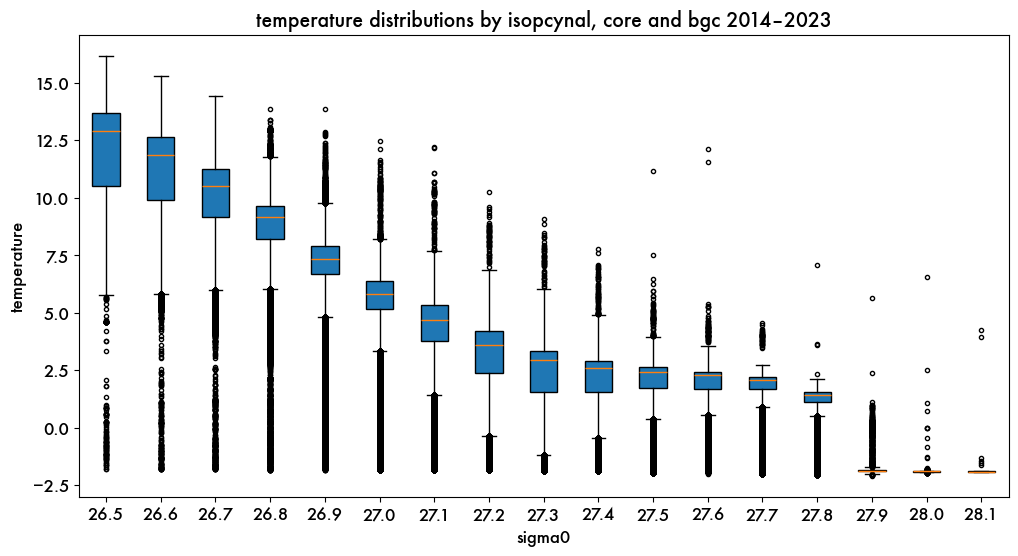

In [ ]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

list = [x.CT for x in isodict.values()]

bplot = ax.boxplot(list, patch_artist=True, tick_labels = isodict.keys(), sym='.')

ax.set_ylabel('CT')
ax.set_xlabel('sigma0')
ax.set_title('CT distributions by isopcynal, core and bgc 2014–2023')

In [ ]:
temp

In [114]:
print("Average pressures for sigma0 values (core and bgc floats)")
for k, v in isodict.items():
    print(k, '\t', v.pressure.mean())

Average pressures for sigma0 values (core and bgc floats)
26.5 	 149.2155480215807
26.6 	 183.51149927455327
26.7 	 219.58860156939426
26.8 	 301.6489350542902
26.9 	 406.71342644782425
27.0 	 504.98023242990956
27.1 	 568.0594192206254
27.2 	 554.6375169337014
27.3 	 524.1388743421224
27.4 	 512.0985162693661
27.5 	 496.1068239633108
27.6 	 501.70258049487524
27.7 	 522.1723660749927
27.8 	 577.7750014702091
27.9 	 248.75245098039215
28.0 	 377.0173657493989
28.1 	 731.6340836012862


In [116]:
print("Number of data points for sigma0 values")
for k, v in isodict.items():
    print(k, '\t', v.pressure.count())

Number of data points for sigma0 values
26.5 	 266349
26.6 	 370806
26.7 	 546198
26.8 	 819854
26.9 	 898607
27.0 	 897733
27.1 	 796998
27.2 	 589062
27.3 	 458292
27.4 	 359971
27.5 	 332959
27.6 	 386360
27.7 	 488501
27.8 	 884228
27.9 	 3264
28.0 	 7486
28.1 	 1555


In [ ]:
sns.boxplot

{'whiskers': [<matplotlib.lines.Line2D at 0x470f87850>,
 'caps': [<matplotlib.lines.Line2D at 0x470f87be0>,
 'boxes': [<matplotlib.lines.Line2D at 0x470f875b0>],
 'medians': [<matplotlib.lines.Line2D at 0x470f93160>],
 'fliers': [<matplotlib.lines.Line2D at 0x470f93400>],
 'means': []}

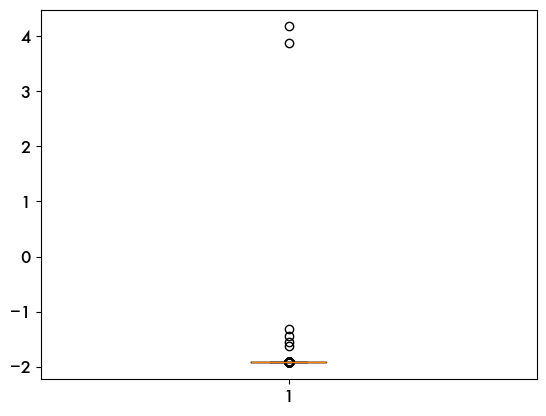

In [ ]:
sns.boxplot(isodict[28.1].CT)

(33.5, 35.0)

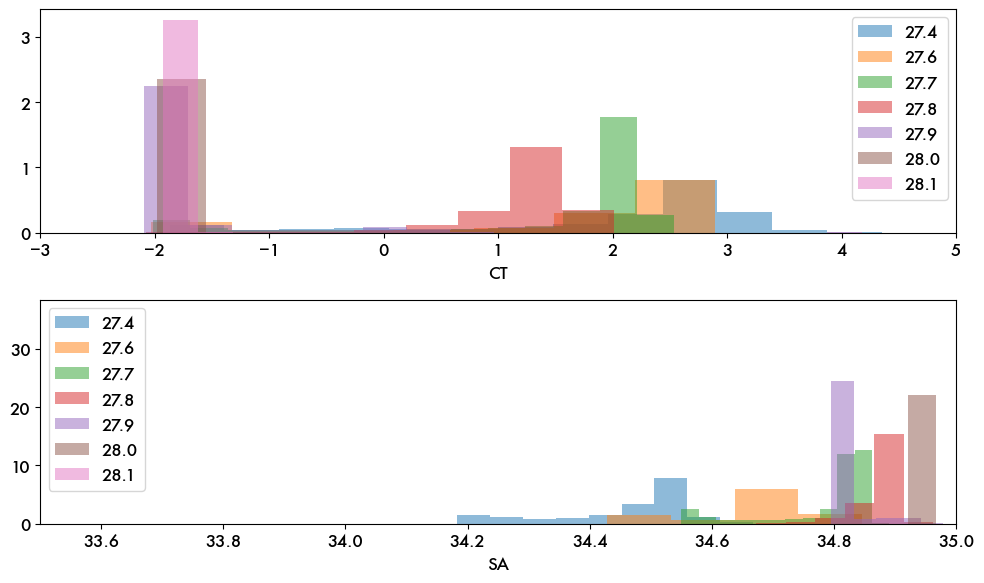

In [78]:
fig = plt.figure(figsize=(10, 6), layout='tight')
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

# for k, group in isodict.items():
for sig in [27.4, 27.6, 27.7, 27.8, 27.9, 28.0, 28.1]:
    ax1.hist(isodict[sig].CT, bins=20, alpha=.5, label=sig, density=True)
    ax2.hist(isodict[sig].SA, bins=20, alpha=.5, label=sig, density=True)

for ax in [ax1,ax2]:
    ax.legend()

ax1.set_xlabel('CT')
ax2.set_xlabel('SA')

ax1.set_xlim([-3, 5])
ax2.set_xlim([33.5, 35])


In [19]:
alldat

,profid,pressure,wmoid,latitude,longitude,datetime,yearday,CT,SA,sigma0,...,salinity_qc,pressure_qc,time_qc,position_qc,temp_error,psal_error,pres_error,pH,pH_qc,pH_error
5538312,5904184_id001,7.550000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062752,33.916040,27.101326,...,8,1,1,1,0.002,0.01,2.4,8.036440,1,0.015321
5538315,5904184_id001,11.730000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062162,33.915951,27.101285,...,8,1,1,1,0.002,0.01,2.4,8.037667,1,0.015321
5538319,5904184_id001,16.220001,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062796,33.915852,27.101172,...,8,1,1,1,0.002,0.01,2.4,8.038201,1,0.015321
5538322,5904184_id001,21.660000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.064599,33.915659,27.100925,...,8,1,1,1,0.002,0.01,2.4,8.038585,1,0.015321
5538326,5904184_id001,26.610000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.063223,33.915310,27.100716,...,8,1,1,1,0.002,0.01,2.4,8.039553,1,0.015321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6336378,5904478_id001,19.440000,5904478,-64.998,0.004,2014-12-18 16:32:43.002000128,351.689387,-1.325542,33.783838,27.052838,...,1,1,1,8,0.002,0.01,2.4,8.059939,1,0.033806
6336379,5904478_id001,21.640001,5904478,-64.998,0.004,2014-12-18 16:32:43.002000128,351.689387,-1.304686,33.835160,27.093575,...,1,1,1,8,0.002,0.01,2.4,8.057148,1,0.033793
6336380,5904478_id001,23.540000,5904478,-64.998,0.004,2014-12-18 16:32:43.002000128,351.689387,-1.321835,33.882449,27.132280,...,1,1,1,8,0.002,0.01,2.4,8.056596,1,0.033794
6337797,5904478_id002,28.260000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,-1.096631,33.790675,27.050690,...,1,1,1,1,0.002,0.01,2.4,8.109830,1,0.033722


In [8]:
def list_profile_DFs(df):
    """ 
    @param df: dataframe with all profiles
    @return: list of dataframes, each with a unique profile
    """
    profids = pd.unique(df.profid)
    profile_DFs = []
    for i in range(len(profids)):
        profile_DFs.append(df[df['profid']==profids[i]].copy())
    return profile_DFs

In [ ]:

def get_isopycnal_signal(platDF, ave_isopycnal, var_thresh=0.01, var_list = ['yearday', 'pressure', 'sigma0', 'nitrate', 'spice']):
    """ 
    Originally from RandomForest_SG mod_DFproc.py

    @param: prof_list: list of glider DF's, using list_profile_DFs 
            ave_isopycnal: list of isopycnal values to find in each profile
            var_thresh: threshold for finding sigma in each profile
            var_list: which variables to keep track of
    @return: Dictionary object containing along-isopycnal variables. 
    """
    prof_list = list_profile_DFs(platDF)
    dLine = dict.fromkeys(ave_isopycnal)

    for sig in ave_isopycnal:
        temp = pd.DataFrame()

        for prof in prof_list:
            # Find all sigma points that are within that threshold
            rangeDF = pd.DataFrame() 
            rangeDF = prof[(prof['sigma0']< (sig+var_thresh)) & (prof['sigma0'] > (sig-var_thresh))].copy()

            # Choose mean of values
            rowdat = rangeDF[var_list].copy().dropna()
            rowdat = np.mean(rowdat, axis=0) #nanmean avoided if you drop nans above.
            temp = pd.concat([temp, rowdat], axis=1)
            
        temp = temp.T
        dLine[sig] = temp

    return dLine
